In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical

In [4]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

In [6]:
x_train_cat = to_categorical(y_train,10)
x_test_cat = to_categorical(y_test,10)

In [7]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [8]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
history_percp = perceptron.fit(x_train_img, x_train_cat, epochs=10, validation_split=0.2,batch_size=32, verbose=1,validation_data=(x_test_img, x_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8835 - loss: 231.6150 - val_accuracy: 0.8912 - val_loss: 216.7124
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8824 - loss: 234.2834 - val_accuracy: 0.8784 - val_loss: 251.0163
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8832 - loss: 233.7569 - val_accuracy: 0.8919 - val_loss: 247.3183
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8834 - loss: 232.0812 - val_accuracy: 0.8854 - val_loss: 241.8389
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8860 - loss: 230.9479 - val_accuracy: 0.8300 - val_loss: 502.8062
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8846 - loss: 228.1143 - val_accuracy: 0.8714 - val_loss: 265.0092
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8858 - loss: 227.2424 - val_accuracy: 0.8852 - val_loss: 230.9986
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accura

In [11]:
acc_percp = perceptron.evaluate(x_test_img, x_test_cat, verbose=0)[1]
print(f"Test accuracy of the perceptron model: {acc_percp:.4f}")

Test accuracy of the perceptron model: 0.8557


In [12]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [13]:
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
history_ann = ann.fit(x_train_img, x_train_cat, epochs=10, validation_split=0.2,batch_size=32, verbose=1,validation_data=(x_test_img, x_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9761 - loss: 0.0838 - val_accuracy: 0.9665 - val_loss: 0.1565
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0833 - val_accuracy: 0.9644 - val_loss: 0.1634
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9793 - loss: 0.0755 - val_accuracy: 0.9691 - val_loss: 0.1460
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9802 - loss: 0.0731 - val_accuracy: 0.9671 - val_loss: 0.1823
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9815 - loss: 0.0671 - val_accuracy: 0.9649 - val_loss: 0.1555
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0641 - val_accuracy: 0.9650 - val_loss: 0.1751
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9821 - loss: 0.0692 - val_accuracy: 0.9671 - val_loss: 0.1536
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0652 - 

In [15]:
acc_ann = ann.evaluate(x_test_img, x_test_cat, verbose=0)[1]
print(f"Test accuracy of the ANN model: {acc_ann:.4f}")

Test accuracy of the ANN model: 0.9663


In [18]:
X_train_cnn = x_train_img.reshape(-1,28,28,1)
X_test_cnn = x_test_img.reshape(-1,28,28,1)

In [19]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [20]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
history_cnn = cnn.fit(X_train_cnn, x_train_cat, epochs=10, validation_split=0.2,batch_size=32, verbose=1,validation_data=(X_test_cnn, x_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9858 - loss: 0.0488 - val_accuracy: 0.9873 - val_loss: 0.0463
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9871 - loss: 0.0455 - val_accuracy: 0.9889 - val_loss: 0.0549
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9878 - loss: 0.0436 - val_accuracy: 0.9863 - val_loss: 0.0768
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9886 - loss: 0.0410 - val_accuracy: 0.9883 - val_loss: 0.0483
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9893 - loss: 0.0387 - val_accuracy: 0.9886 - val_loss: 0.0593
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9882 - loss: 0.0441 - val_accuracy: 0.9897 - val_loss: 0.0560
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9901 - loss: 0.0399 - val_accuracy: 0.9870 - val_loss: 0.0580
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9892 - loss

In [22]:
acc_cnn = cnn.evaluate(X_test_cnn, x_test_cat, verbose=0)[1]
print(f"Test accuracy of the CNN model: {acc_cnn:.4f}")

Test accuracy of the CNN model: 0.9889


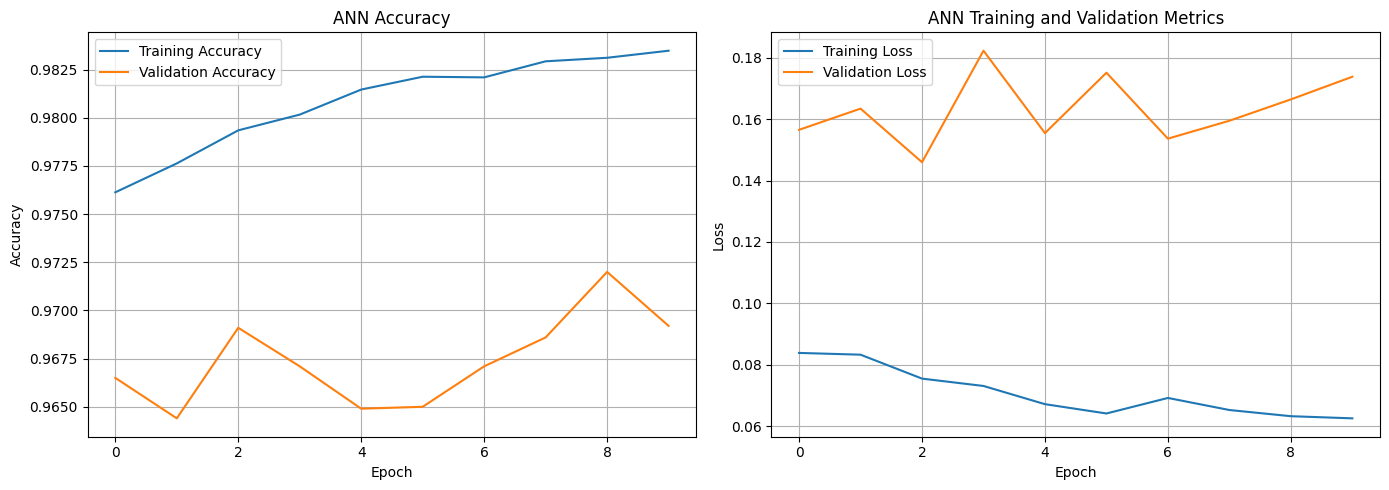

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ann.history['accuracy'], label='Training Accuracy')
axes[0].plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('ANN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_ann.history['loss'], label='Training Loss')
axes[1].plot(history_ann.history['val_loss'], label='Validation Loss')
axes[1].set_title('ANN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
plt.title('ANN Training and Validation Metrics')

plt.tight_layout()
plt.show()

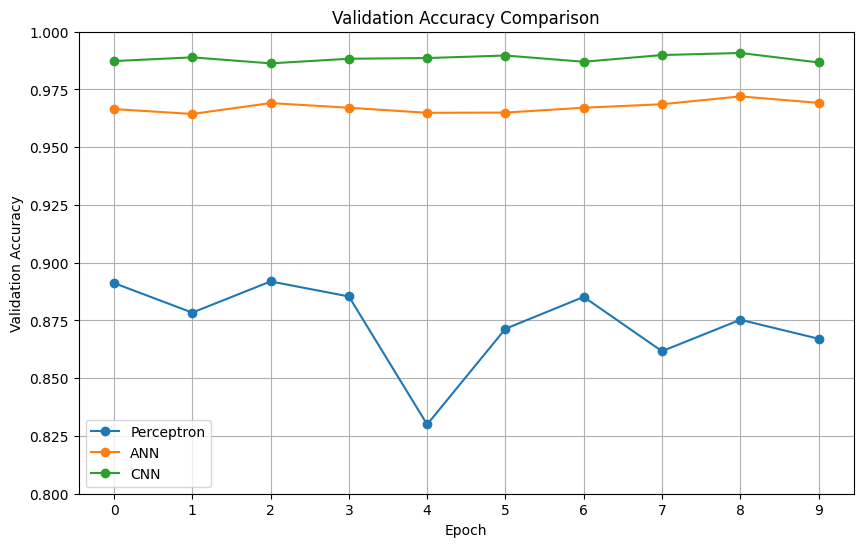

Final Perceptron validation accuracy: 0.8671
Final ANN validation accuracy: 0.9692
Final CNN validation accuracy: 0.9867


In [37]:
# Compare validation accuracy for all three models
val_acc_percp = history_percp.history['val_accuracy']
val_acc_ann = history_ann.history['val_accuracy']
val_acc_cnn = history_cnn.history['val_accuracy']

plt.figure(figsize=(10, 6))

plt.plot(val_acc_percp, marker='o', label='Perceptron')
plt.plot(val_acc_ann, marker='o', label='ANN')
plt.plot(val_acc_cnn, marker='o', label='CNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(range(len(val_acc_ann)))
plt.ylim(0, 1)
plt.grid(True)
plt.ylim(0.8, 1)
plt.legend()
plt.show()

print(f"Final Perceptron validation accuracy: {val_acc_percp[-1]:.4f}")
print(f"Final ANN validation accuracy: {val_acc_ann[-1]:.4f}")
print(f"Final CNN validation accuracy: {val_acc_cnn[-1]:.4f}")

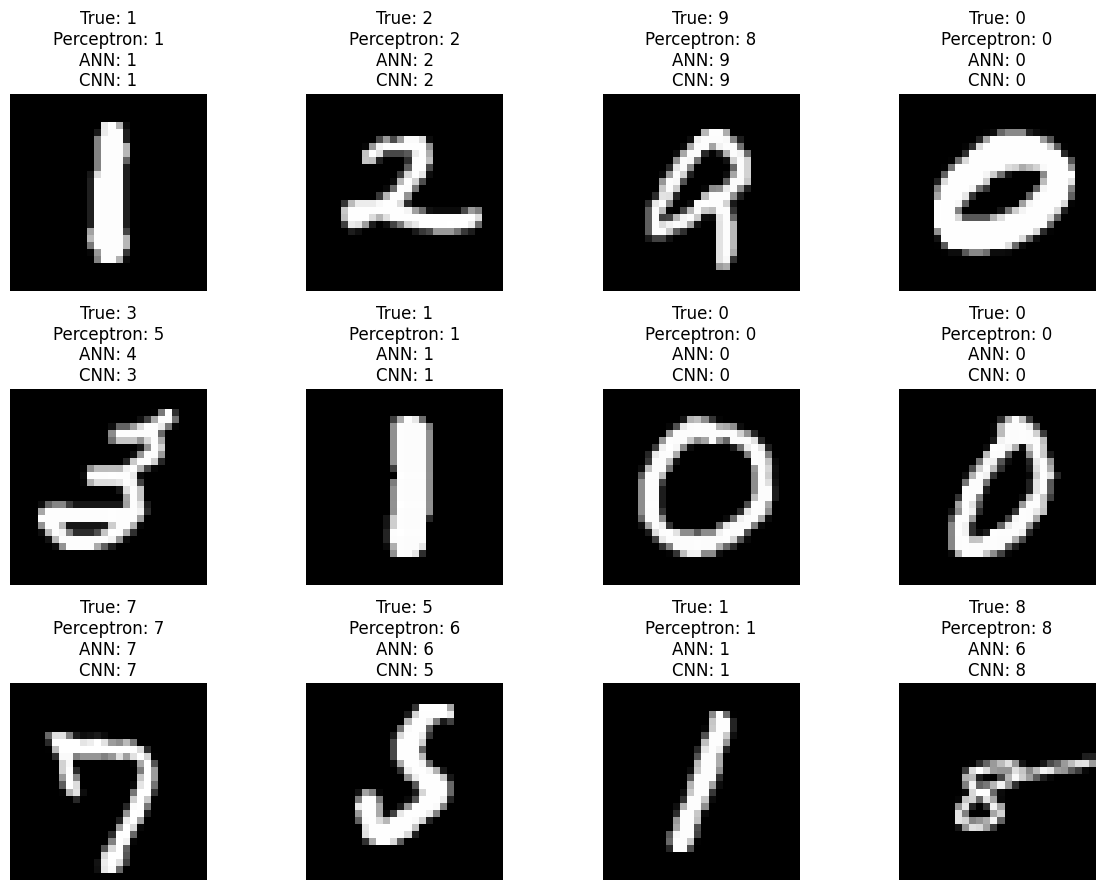

In [40]:
# Display MNIST images with predictions from all three models
n_images = 12
indices = np.random.choice(len(x_test_img), n_images, replace=False)

ann_predictions = np.argmax(ann.predict(x_test_img[indices], verbose=0), axis=1)
cnn_predictions = np.argmax(cnn.predict(X_test_cnn[indices], verbose=0), axis=1)
percp_predictions = np.argmax(perceptron.predict(x_test_img[indices], verbose=0), axis=1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for i, (ax, index) in enumerate(zip(axes, indices)):
    ax.imshow(x_test_img[index], cmap='gray')
    ax.set_title(
        f"True: {y_test[index]}\n"
        f"Perceptron: {percp_predictions[i]}\n"
        f"ANN: {ann_predictions[i]}\n"
        f"CNN: {cnn_predictions[i]}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()